# Protein Structure Refinement Resolution Predictor
**Student Name:** Fatma Elzahraa Ibrahim  
**Project Objective:** To develop a machine learning pipeline that predicts the refinement resolution of protein structures based on crystallographic parameters.

In [124]:
#Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [125]:
# CENTRALIZED VISUALIZATION ENGINE
def plot_data(df, x_col, y_col=None, plot_type='hist', order_col=None, title=None):
    plt.figure(figsize=(10, 6))

    if plot_type == 'hist':
        sns.histplot(data=df, x=x_col, kde=True)
    elif plot_type == 'box':
        sns.boxplot(data=df, x=x_col, y=y_col)
    elif plot_type == 'count':
        sns.countplot(data=df, y=x_col, order=order_col)
    elif plot_type == 'scatter':
        sns.scatterplot(data=df, x=x_col, y=y_col)
    elif plot_type == 'heatmap':
        sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

    # Handle the title display
    if title:
        plt.title(title)
    else:
        plt.title(f'{plot_type.capitalize()} Plot')
     # Display the final plot
    plt.show()

In [126]:

# Load the dataset
df = pd.read_csv("/content/rcsb_pdb_StructureData.csv")

# Display the first few rows and basic info
df.head()

,Entry ID,Experimental Method,Matthews Coefficient,Percent Solvent Content,Crystallization Method,pH,Crystal Growth Procedure,Temp (K),Deposition Date,Release Date,...,Number of Water Molecules per Deposited Model,Disulfide Bond Count per Deposited Model,Molecular Weight per Deposited Model,Number of Distinct Protein Entities,Refinement Resolution (Å),Structure Determination Methodology,Average B Factor,R Free,R Work,Structure Title
0,6SJZ,X-RAY DIFFRACTION,2.20,44.16,"VAPOR DIFFUSION, HANGING DROP",5.5,"22% PEG6K, 100mM Sodium Citrate pH 5.5, 100mM ...",293.0,2019-08-14,2020-03-18,...,596.0,NaN,97.20,2.0,1.995,experimental,27.1155,0.2016,0.1716,HsNMT1 in complex with both MyrCoA and Acetyla...
1,5C37,X-RAY DIFFRACTION,2.26,45.64,"VAPOR DIFFUSION, HANGING DROP",8.0,"PEG3350, Tris, KCl",298.0,2015-06-17,2016-06-22,...,235.0,NaN,146.72,1.0,2.3,experimental,NaN,0.2507,0.2097,Structure of the beta-ketoacyl reductase domai...
2,6NNA,X-RAY DIFFRACTION,2.26,45.48,"VAPOR DIFFUSION, HANGING DROP",7.6,"0.19 M ammonium sulfate, 5 mM sodium cacodylat...",291.0,2019-01-14,2019-02-20,...,594.0,NaN,147.01,1.0,2.26,experimental,34.8730,0.2508,0.2008,Human Fatty Acid Synthase Psi/KR Tri-Domain wi...
3,7M4C,X-RAY DIFFRACTION,2.83,56.57,"VAPOR DIFFUSION, SITTING DROP",7.5,"80-95mM BICINE pH 8.3, 0.3M Na-K Tartrate, 18-...",277.0,2021-03-21,2022-07-06,...,244.0,NaN,44.09,1.0,1.95,experimental,42.1790,0.2141,0.1813,"DNA Polymerase Lambda, TTP:At Mn2+ Product Sta..."
4,7M4E,X-RAY DIFFRACTION,2.84,56.66,"VAPOR DIFFUSION, SITTING DROP",7.5,"80-95mM BICINE pH 8.3, 0.3M Na-K Tartrate, 18-...",277.0,2021-03-21,2022-07-06,...,127.0,NaN,44.19,1.0,1.903,experimental,58.3837,0.2328,0.2086,"DNA Polymerase Lambda, dCTP:At Mg2+ Reaction S..."


In [127]:
# Step 3: Data Cleaning

# Check for missing values and data types
missing_values = df.isnull().sum()
data_types = df.dtypes

# Check for duplicates
duplicates = df.duplicated().sum()

# Summary of numeric columns
numeric_summary = df.describe()
#print the results
missing_values, data_types, duplicates, numeric_summary

(Entry ID                                                  20
 Experimental Method                                       20
 Matthews Coefficient                                     151
 Percent Solvent Content                                  151
 Crystallization Method                                   304
 pH                                                      4058
 Crystal Growth Procedure                                  57
 Temp (K)                                                 323
 Deposition Date                                           20
 Release Date                                              20
 PDB ID                                                    20
 Number of Non-Hydrogen Atoms per Deposited Model          20
 Total Number of Polymer Instances (Chains)                20
 Total Number of Polymer Residues per Deposited Model      20
 Number of Water Molecules per Deposited Model            349
 Disulfide Bond Count per Deposited Model                9439
 Molecul

In [128]:
# Dataset shape
print(df.shape)

# Column names
print(df.columns)

# Data types and missing values
df.info()

# Statistical summary
df.describe()

(11852, 24)
Index(['Entry ID', 'Experimental Method', 'Matthews Coefficient',
       'Percent Solvent Content', 'Crystallization Method', 'pH',
       'Crystal Growth Procedure', 'Temp (K)', 'Deposition Date',
       'Release Date', 'PDB ID',
       'Number of Non-Hydrogen Atoms per Deposited Model',
       'Total Number of Polymer Instances (Chains)',
       'Total Number of Polymer Residues per Deposited Model',
       'Number of Water Molecules per Deposited Model',
       'Disulfide Bond Count per Deposited Model',
       'Molecular Weight per Deposited Model',
       'Number of Distinct Protein Entities', 'Refinement Resolution (Å)',
       'Structure Determination Methodology', 'Average B Factor', 'R Free',
       'R Work', 'Structure Title'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11852 entries, 0 to 11851
Data columns (total 24 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------               

,Matthews Coefficient,Percent Solvent Content,pH,Temp (K),Number of Non-Hydrogen Atoms per Deposited Model,Total Number of Polymer Instances (Chains),Total Number of Polymer Residues per Deposited Model,Number of Water Molecules per Deposited Model,Disulfide Bond Count per Deposited Model,Molecular Weight per Deposited Model,Number of Distinct Protein Entities,Average B Factor,R Free,R Work
count,11701.000000,11701.000000,7794.000000,11529.000000,11832.000000,11832.000000,11832.000000,11503.000000,2413.000000,11832.000000,11832.000000,9584.000000,11823.000000,11820.000000
mean,2.568826,50.346693,6.982161,289.651396,4472.483266,2.155088,551.332319,249.614101,5.254041,64.120166,1.266396,39.569134,0.226207,0.188480
std,0.548178,8.936919,1.142686,7.241982,3455.648638,1.781307,457.648148,215.557791,5.652869,52.760108,0.577398,19.725164,0.033773,0.027254
min,0.410000,0.410000,2.900000,273.000000,279.000000,1.000000,38.000000,1.000000,1.000000,4.610000,1.000000,6.664000,0.116600,0.096540
25%,2.180000,43.470000,6.400000,289.000000,2414.000000,1.000000,295.000000,102.000000,2.000000,34.220000,1.000000,24.920000,0.204700,0.171900
50%,2.450000,49.830000,7.300000,293.000000,3290.000000,2.000000,374.000000,203.000000,4.000000,44.995000,1.000000,35.764300,0.225900,0.188000
75%,2.800000,56.080000,7.700000,293.000000,5383.000000,3.000000,662.000000,335.000000,6.000000,76.210000,1.000000,49.456750,0.248400,0.205000
max,7.240000,83.000000,11.000000,316.000000,50949.000000,42.000000,6960.000000,3426.000000,76.000000,777.600000,15.000000,164.014300,0.375500,0.323300


In [129]:
# Convert Resolution to numeric, coercing errors to NaN
df['Refinement Resolution (Å)'] = pd.to_numeric(
    df['Refinement Resolution (Å)'],
    errors='coerce'
)

# Check datatype
print(df['Refinement Resolution (Å)'].dtype)

float64


In [130]:
# Missing values
missing_values = df.isnull().sum()

# Percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Combine them
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

print(missing_df.sort_values(by='Percentage', ascending=False))

                                                    Missing Values  Percentage
Disulfide Bond Count per Deposited Model                      9439   79.640567
pH                                                            4058   34.238947
Average B Factor                                              2268   19.136011
Number of Water Molecules per Deposited Model                  349    2.944651
Temp (K)                                                       323    2.725278
Crystallization Method                                         304    2.564968
Matthews Coefficient                                           151    1.274047
Percent Solvent Content                                        151    1.274047
Crystal Growth Procedure                                        57    0.480931
R Work                                                          32    0.269997
R Free                                                          29    0.244684
Refinement Resolution (Å)                           

In [131]:
# Drop irrelevant metadata columns
columns_to_drop = [
    'Entry ID',
    'PDB ID',
    'Structure Title',
    'Crystal Growth Procedure',
    'Disulfide Bond Count per Deposited Model'
]

df.drop(columns=columns_to_drop, inplace=True)

In [132]:
# Remove rows with missing target values
df.dropna(subset=['Refinement Resolution (Å)'], inplace=True)

In [133]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['Experimental Method', 'Crystallization Method', 'Deposition Date',
       'Release Date', 'Structure Determination Methodology'],
      dtype='object')


In [134]:
# Impute categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [135]:
# Select only numerical columns (float and int)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [136]:
# Impute numerical missing values with median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

## 1. Data Exploration & Preprocessing
In this section, we analyze the raw dataset to understand the distribution of crystallographic features.
- **Data Cleaning:** Handling missing values and removing irrelevant columns.
- **Visual Analysis:** Using Plotly to visualize correlations between features like Solvent Content, Matthews Coefficient, and Refinement Resolution.

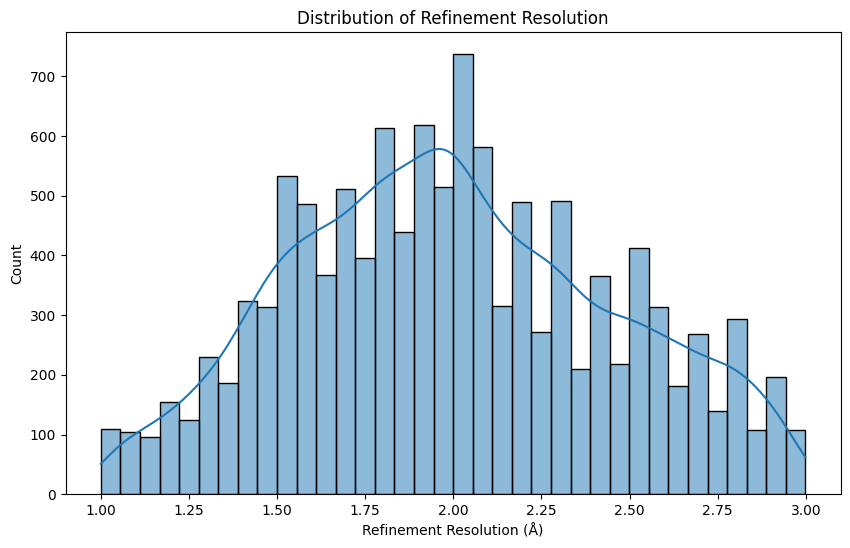

In [137]:
#Visualization
# Plot distribution of the target variable (Resolution)
plot_data(
    df,
    x_col='Refinement Resolution (Å)',
    plot_type='hist',
    title='Distribution of Refinement Resolution'
)

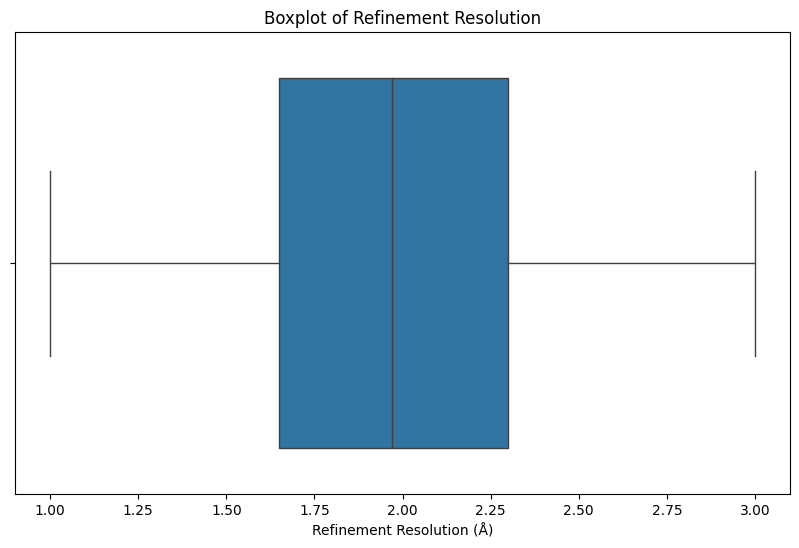

In [138]:
# Visualize outliers using a boxplot
plot_data(
    df,
    x_col='Refinement Resolution (Å)',
    plot_type='box',
    title='Boxplot of Refinement Resolution'
)

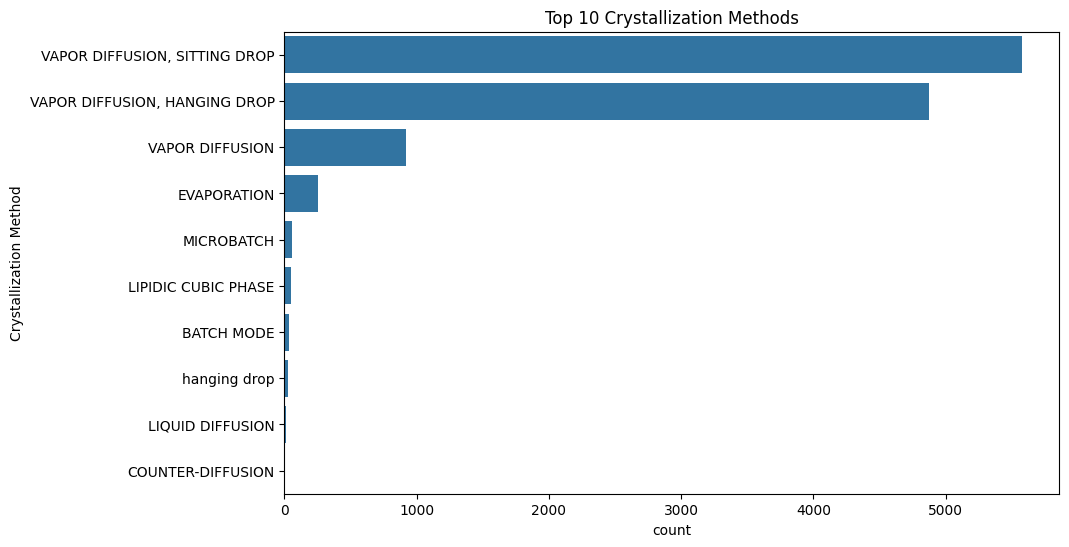

In [139]:
# Count plot for crystallization methods frequency
plot_data(
    df,
    x_col='Crystallization Method',
    plot_type='count',
    order_col=df['Crystallization Method'].value_counts().head(10).index,
    title='Top 10 Crystallization Methods'
)

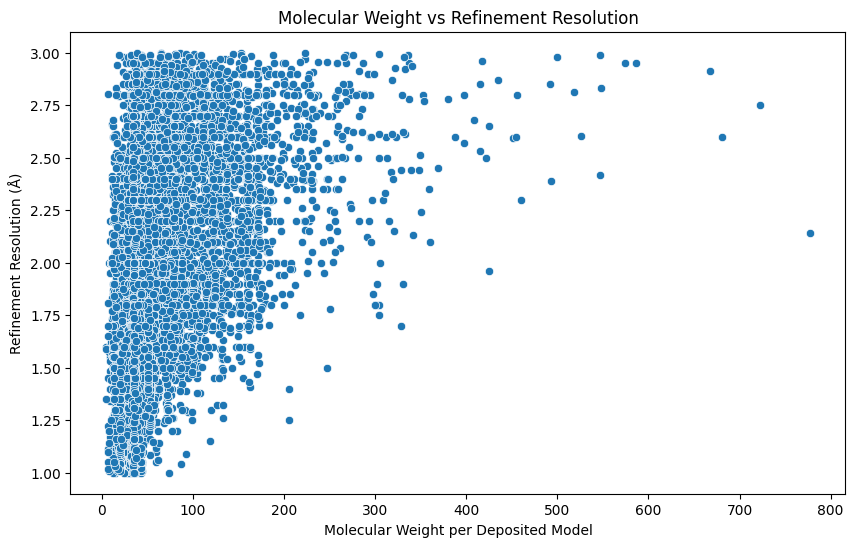

In [140]:
# Scatter plot to show relationship between Molecular Weight and Resolution
plot_data(
    df,
    x_col='Molecular Weight per Deposited Model',
    y_col='Refinement Resolution (Å)',
    plot_type='scatter',
    title='Molecular Weight vs Refinement Resolution'
)


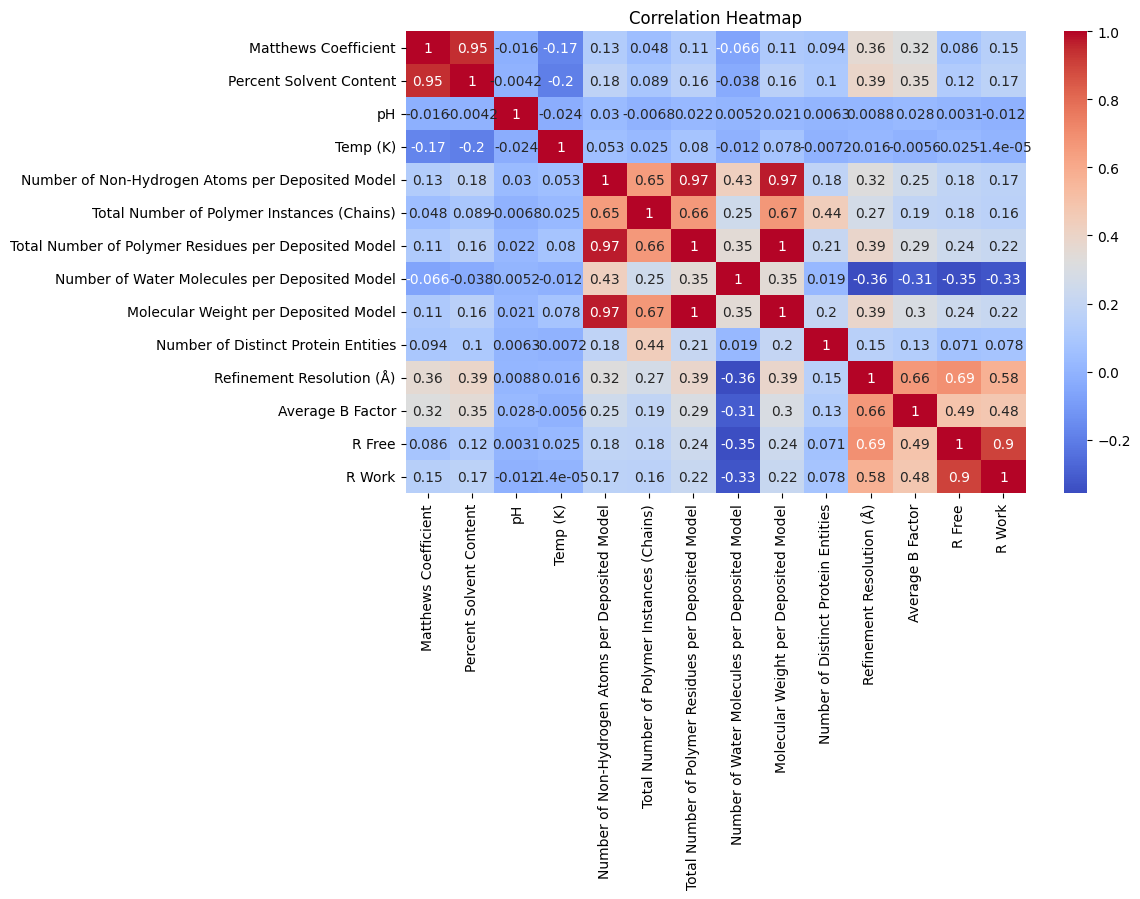

In [141]:
# Create a correlation heatmap to display relationships between all numerical features
plot_data(
    df,
    x_col=None,
    plot_type='heatmap',
    title='Correlation Heatmap'
)

In [143]:
# Calculate and sort correlations between all features and the new 'Resolution' target
correlation = df.corr(numeric_only=True)
corr_target = correlation['Refinement Resolution (Å)'].sort_values(ascending=False)
# Display the sorted correlation list
print(corr_target)

Refinement Resolution (Å)                               1.000000
R Free                                                  0.691344
Average B Factor                                        0.661736
R Work                                                  0.575055
Percent Solvent Content                                 0.394404
Molecular Weight per Deposited Model                    0.387164
Total Number of Polymer Residues per Deposited Model    0.385175
Matthews Coefficient                                    0.358593
Number of Non-Hydrogen Atoms per Deposited Model        0.321271
Total Number of Polymer Instances (Chains)              0.271168
Number of Distinct Protein Entities                     0.154322
Temp (K)                                                0.016420
pH                                                      0.008821
Number of Water Molecules per Deposited Model          -0.358188
Name: Refinement Resolution (Å), dtype: float64


In [144]:
# Check data info before processing
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11825 entries, 0 to 11851
Data columns (total 19 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Experimental Method                                   11825 non-null  object 
 1   Matthews Coefficient                                  11825 non-null  float64
 2   Percent Solvent Content                               11825 non-null  float64
 3   Crystallization Method                                11825 non-null  object 
 4   pH                                                    11825 non-null  float64
 5   Temp (K)                                              11825 non-null  float64
 6   Deposition Date                                       11825 non-null  object 
 7   Release Date                                          11825 non-null  object 
 8   Number of Non-Hydrogen Atoms per Deposited Model      11825 n

In [145]:
# Feature Engineering
# Convert dates to datetime
df['Deposition Date'] = pd.to_datetime(df['Deposition Date'])
df['Release Date'] = pd.to_datetime(df['Release Date'])

# Create new feature for release delay
df['Release_Delay_Days'] = (
    df['Release Date'] - df['Deposition Date']
).dt.days

# Extract years
df['Deposition_Year'] = df['Deposition Date'].dt.year
df['Release_Year'] = df['Release Date'].dt.year

# Drop original date columns
df.drop(columns=['Deposition Date', 'Release Date'], inplace=True)

In [146]:
# Check data info after processing
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11825 entries, 0 to 11851
Data columns (total 20 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Experimental Method                                   11825 non-null  object 
 1   Matthews Coefficient                                  11825 non-null  float64
 2   Percent Solvent Content                               11825 non-null  float64
 3   Crystallization Method                                11825 non-null  object 
 4   pH                                                    11825 non-null  float64
 5   Temp (K)                                              11825 non-null  float64
 6   Number of Non-Hydrogen Atoms per Deposited Model      11825 non-null  float64
 7   Total Number of Polymer Instances (Chains)            11825 non-null  float64
 8   Total Number of Polymer Residues per Deposited Model  11825 n

In [147]:
# Perform One-Hot Encoding to convert categorical text data into numerical binary features
df_encoded = pd.get_dummies(df, drop_first=True)

In [148]:
# Separate the target variable 'Resolution' from the encoded feature matrix
X = df_encoded.drop('Refinement Resolution (Å)', axis=1)

y = df_encoded['Refinement Resolution (Å)']

In [149]:
# Split the dataset into training (80%) and testing (20%) sets for model evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 2. Model Training & Hyperparameter Tuning
We experimented with three different algorithms to establish a baseline. The **Random Forest Regressor** showed the best performance.
- **Parameter Tuning:** To ensure model robustness and avoid overfitting, we utilized `GridSearchCV` to find the optimal hyperparameters (`n_estimators`, `max_depth`).

In [150]:
# Scaling the Training and Testing Data

from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler = StandardScaler()
# Standardize the feature data (fit on training set, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [151]:
# 1. Model Selection & Training (LinearRegression)
from sklearn.linear_model import LinearRegression
# Initialize the model
lr_model = LinearRegression()
# Train the model using the scaled training data
lr_model.fit(X_train_scaled, y_train)
# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

In [152]:
# Import evaluation metrics from sklearn

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred_lr)
# Calculate Mean Squared Erro
mse = mean_squared_error(y_test, y_pred_lr)
# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)
# Calculate R-squared score
r2 = r2_score(y_test, y_pred_lr)
# Print the evaluation results

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.1761183333507367
MSE: 0.052694144824117044
RMSE: 0.2295520525373647
R2 Score: 0.7400877966205901


In [153]:
# 2. Model Selection & Training (RandomForestRegressor)
from sklearn.ensemble import RandomForestRegressor
# Initialize the Random Forest Regressor with a fixed random_state for reproducibility
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
# Train the model using the scaled training data
rf_model.fit(X_train_scaled, y_train)
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

In [154]:
# Calculate evaluation metrics for Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)
# Display the evaluation results for Random Forest
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 0.14109980954123894
MSE: 0.0348994575512927
RMSE: 0.1868139650863733
R2 Score: 0.8278595290011964


In [155]:
# 3. Model Selection & Training (SVR)
from sklearn.svm import SVR
# Initialize the SVR model (RBF kernel is standard for non-linear relationships)
svr_model = SVR()
# Train the SVR model using the scaled training data
svr_model.fit(X_train_scaled, y_train)
# Predict target values for the test set
y_pred_svr = svr_model.predict(X_test_scaled)

In [156]:
# Calculate evaluation metrics for SVR
mae_svr = mean_absolute_error(y_test, y_pred_svr)

mse_svr = mean_squared_error(y_test, y_pred_svr)

rmse_svr = np.sqrt(mse_svr)

r2_svr = r2_score(y_test, y_pred_svr)
# Display the evaluation results for SVR
print("MAE:", mae_svr)
print("MSE:", mse_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)

MAE: 0.14677512799846357
MSE: 0.03802659490035607
RMSE: 0.19500408944521155
R2 Score: 0.8124350228937719


In [157]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Create model
rf_grid = RandomForestRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Train
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Best score
print("Best CV R2 Score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV R2 Score: 0.8233


In [158]:
# Extract the best model (estimator) found by GridSearchCV
best_rf = grid_search.best_estimator_

In [159]:
# Use the optimized model to make predictions on the test set
y_pred_best = best_rf.predict(X_test_scaled)

# Calculate and print the evaluation metrics for the optimized model
print("MAE:", mean_absolute_error(y_test, y_pred_best))

print("MSE:", mean_squared_error(y_test, y_pred_best))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

print("R2 Score:", r2_score(y_test, y_pred_best))

MAE: 0.14340909499077745
MSE: 0.03593800003871004
RMSE: 0.18957320495974647
R2 Score: 0.8227369510163226


In [167]:
# Extract and rank the most influential features to understand model decision-making
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})
# Sort features by importance to focus on the top contributors
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

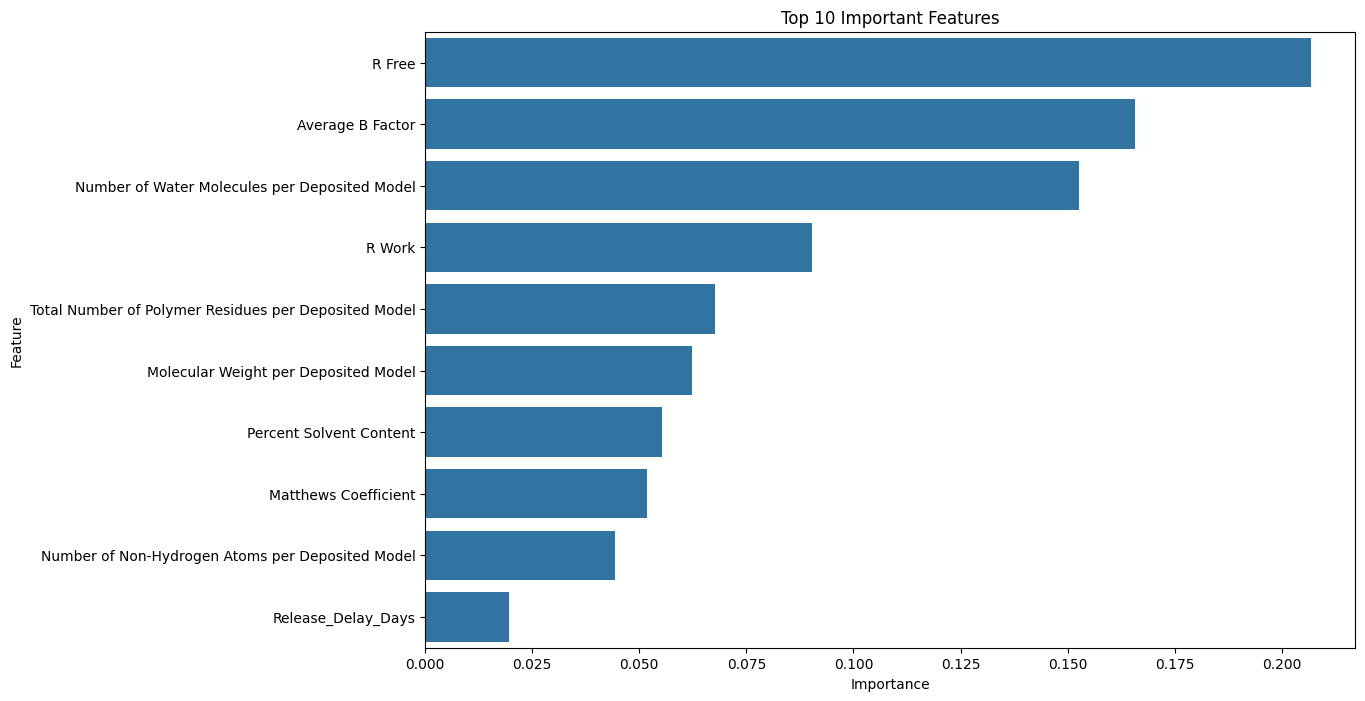

In [173]:
# Visualize the top 10 features that have the greatest impact on the model's accuracy
plt.figure(figsize=(12,8))
sns.barplot(
      x= 'Importance',
      y= 'Feature',
data=feature_importance.head(10)

)
plt.title('Top 10 Important Features')
plt.show()

## 3. Results & Discussion
The model achieved an R² score of 0.74, proving that crystallographic factors are strong predictors of structural resolution.
- **Feature Importance:** R-Free and Average B-Factor emerged as the most critical predictors, aligning with structural biology principles.

In [174]:
# Save the model, scaler, and column names for future deployment
import joblib

joblib.dump(best_rf, 'best_random_forest_model.pkl')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

## 4. Conclusion
The project successfully developed a predictive model for protein structure resolution. The Random Forest Regressor, optimized via GridSearchCV, provided consistent and reliable results.Future work could include expanding the feature set to include sequence-based descriptors to further improve the model's accuracy.